In [1]:
#run the following for the first time
# try:
#     %pip install --user "oracledb" --no-warn-script-location
# except Exception as e:
#     print("\x1b[31m\u2717 Unexpected error! Please contact course staff\n" +
#          "Please include the entire text above and below in your message.")
#     raise

In [7]:
import oracledb
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(user="ora_lukeni", password="a54131032", dsn=dsn)

In [4]:
cur = connection.cursor()

In [30]:

# Define the grouped SQL query
query_line = """
SELECT year_quarter, COUNT(*) AS count
FROM (
    SELECT year_quarter FROM BENEFICIARY
    UNION ALL
    SELECT year_quarter FROM PATIENTS
    UNION ALL
    SELECT year_quarter FROM SERVICECOUNT
    WHERE service_type != 'Store and forward'

)
WHERE year_quarter NOT IN (
    '2020-Overall', '2021-Overall', '2022-Overall', '2023-Overall'
)
GROUP BY year_quarter
ORDER BY year_quarter

"""

# Execute and fetch results into pandas DataFrame
cur.execute(query_line)
rows = cur.fetchall()

# Extract column names
columns = [desc[0] for desc in cur.description]

# Load into pandas DataFrame
line = pd.DataFrame(rows, columns=columns)

# Display the result
print(line)


   YEAR_QUARTER  COUNT
0        2018-1    107
1        2018-2    106
2        2018-3    122
3        2018-4    127
4        2019-1    138
5        2019-2    135
6        2019-3    140
7        2019-4    145
8        2020-1   1265
9        2020-2   1310
10       2020-3   1265
11       2020-4   1271
12       2021-1   1274
13       2021-2   2137
14       2021-3   2216
15       2021-4   1474
16       2022-1   1788
17       2022-2   1781
18       2022-3   1444
19       2022-4   1444
20       2023-1   1076
21       2023-2   1077
22       2023-3   1077
23       2023-4   1076
24       2024-1   1076
25       2024-2   1076


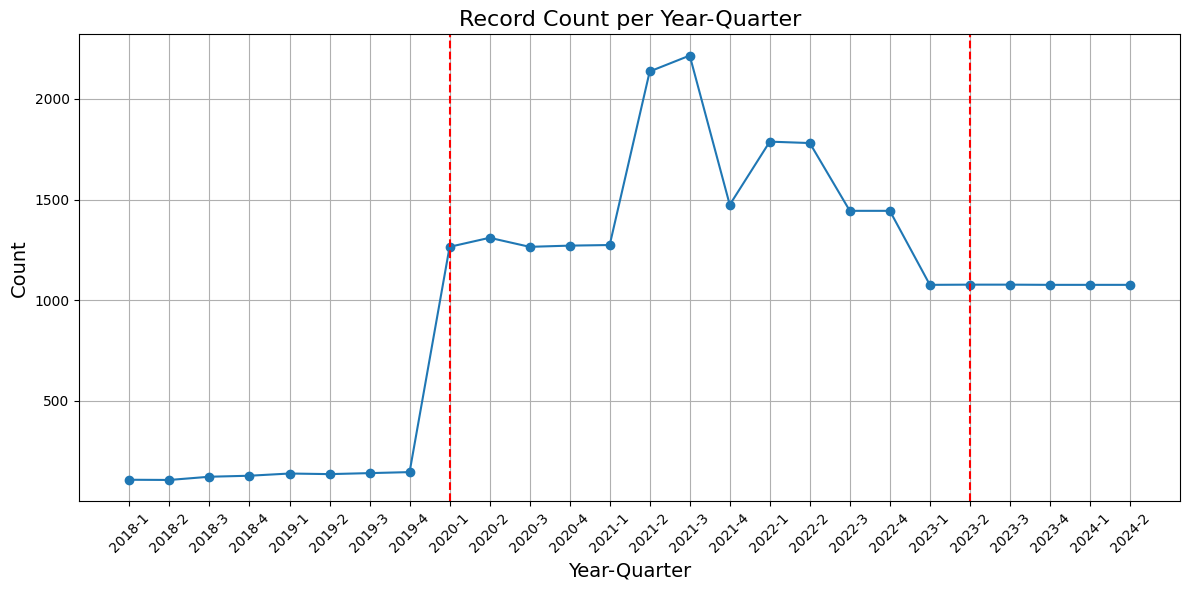

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(line['YEAR_QUARTER'], line['COUNT'], marker='o')

# Customize axis labels with increased font size
plt.title('Record Count per Year-Quarter', fontsize=16)
plt.xlabel('Year-Quarter', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Add red vertical dotted lines
plt.axvline(x='2020-1', color='red', linestyle='--', linewidth=1.5)
plt.axvline(x='2023-2', color='red', linestyle='--', linewidth=1.5)

# Improve x-axis readability
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

#plt.savefig('figures/line_chart.png', dpi=300)

# Show plot
plt.show()


In [17]:


query_avg = """
SELECT 
    CASE
        WHEN year_quarter BETWEEN '2018-1' AND '2019-4' THEN 'Pre-Pandemic'
        WHEN year_quarter BETWEEN '2020-1' AND '2023-1' THEN 'During Pandemic'
        WHEN year_quarter >= '2023-2' THEN 'Post-Pandemic'
    END AS period,
    AVG(count) AS avg_count
FROM (
    SELECT year_quarter, COUNT(*) AS count
    FROM (
        SELECT year_quarter FROM BENEFICIARY
        UNION ALL
        SELECT year_quarter FROM PATIENTS
        UNION ALL
        SELECT year_quarter FROM SERVICECOUNT
        WHERE service_type != 'Store and forward'
    )
    WHERE year_quarter NOT IN ('2020-Overall', '2021-Overall', '2022-Overall', '2023-Overall')
    GROUP BY year_quarter
)
GROUP BY 
    CASE
        WHEN year_quarter BETWEEN '2018-1' AND '2019-4' THEN 'Pre-Pandemic'
        WHEN year_quarter BETWEEN '2020-1' AND '2023-1' THEN 'During Pandemic'
        WHEN year_quarter >= '2023-2' THEN 'Post-Pandemic'
    END
ORDER BY 
    CASE
        WHEN period = 'Pre-Pandemic' THEN 1
        WHEN period = 'During Pandemic' THEN 2
        WHEN period = 'Post-Pandemic' THEN 3
    END
"""


# Execute and fetch results into pandas DataFrame
cur.execute(query_avg)
rows = cur.fetchall()

# Extract column names
columns = [desc[0] for desc in cur.description]

# Load into pandas DataFrame
ave = pd.DataFrame(rows, columns=columns)

# Display the result
print(ave)

            PERIOD    AVG_COUNT
0     Pre-Pandemic   127.500000
1  During Pandemic  1518.846154
2    Post-Pandemic  1076.400000


In [18]:
#ave.to_csv("figures/period_avg_count.csv", index=False)